# The Pulse of the City
## An Investigation into the Changing State of the NYC Taxi Ecosystem

**Investigator Roll Number (last 4 digits):** 0458  
**Analysis Window:** Derived mathematically in Act 1 below

---
## Setup
Run this cell first to install all required libraries, then run the rest of the notebook.

In [1]:
# Install required libraries — run once before anything else
import subprocess, sys

packages = ['numpy', 'matplotlib', 'seaborn', 'sympy', 'pandas', 'scipy', 'pyarrow', 'requests']
subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + packages)
print('All dependencies installed successfully.')

All dependencies installed successfully.


In [2]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sympy import symbols, diff, solve, Rational

warnings.filterwarnings('ignore')
np.random.seed(42)

# Plot style applied once, used everywhere
plt.style.use('seaborn-v0_8-whitegrid')

# Color convention: green = stability, red = stress, amber = caution
COLOR_STABILITY = '#2ecc71'
COLOR_STRESS    = '#e74c3c'
COLOR_CAUTION   = '#f39c12'
COLOR_NEUTRAL   = '#3498db'

# Output directory for saved figures
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Month name lookup
MONTH_NAMES = {
    1: 'January',  2: 'February', 3: 'March',    4: 'April',
    5: 'May',      6: 'June',     7: 'July',      8: 'August',
    9: 'September',10: 'October', 11: 'November', 12: 'December'
}

print('Setup complete.')

Setup complete.


---
## Act 1 — A Number That Chooses the Story

Before any data is accessed, the analysis window must be derived mathematically from the investigator's roll number.

The commissioner's team believes the system has **zones of stability** and **zones of stress** — but cannot locate them. The function below encodes where behaviour changes. The critical points of this function define the months we investigate.

> *"When you look matters as much as what you look at."*

In [3]:
# ── Step 1: Roll number digits ───────────────────────────────────────────────
W, X, Y, Z = 0, 4, 5, 8   # Last four digits of roll number

print(f'Roll number last four digits: W={W}, X={X}, Y={Y}, Z={Z}')
print(f'Sum: {W} + {X} + {Y} + {Z} = {W+X+Y+Z}')

Roll number last four digits: W=0, X=4, Y=5, Z=8
Sum: 0 + 4 + 5 + 8 = 17


In [4]:
# ── Step 2: Compute R as the digital root of (W+X+Y+Z) ──────────────────────
def digital_root(n):
    """Repeatedly sum digits until a single digit remains."""
    while n >= 10:
        n = sum(int(d) for d in str(n))
    return n

digit_sum = W + X + Y + Z
R = digital_root(digit_sum)

print(f'Digital root of {digit_sum} = {R}')
print(f'R = {R}')

Digital root of 17 = 8
R = 8


In [5]:
# ── Step 3: Define f(x) and compute f'(x) symbolically ──────────────────────
x = symbols('x')

# f(x) = x^3/3 - R*x^2 + (R^2 - 1)*x
f_x = Rational(1, 3) * x**3 - R * x**2 + (R**2 - 1) * x

# First derivative
f_prime = diff(f_x, x)

print(f'f(x)  = x^3/3 - {R}*x^2 + ({R}^2 - 1)*x')
print(f'      = x^3/3 - {R}*x^2 + {R**2 - 1}*x')
print()
print(f"f'(x) = {f_prime}")

f(x)  = x^3/3 - 8*x^2 + (8^2 - 1)*x
      = x^3/3 - 8*x^2 + 63*x

f'(x) = x**2 - 16*x + 63


In [6]:
# ── Step 4: Solve f'(x) = 0 to find critical points ─────────────────────────
critical_points = solve(f_prime, x)

# Keep only real solutions and sort them
real_critical = sorted([float(cp) for cp in critical_points if cp.is_real])

if len(real_critical) < 2:
    raise ValueError('No real critical points found — check roll number digits.')

month_start = int(round(real_critical[0]))
month_end   = int(round(real_critical[1]))

print("Critical points of f'(x) = 0:")
print(f'  x1 = {real_critical[0]:.4f}  ->  Month {month_start} ({MONTH_NAMES[month_start]})')
print(f'  x2 = {real_critical[1]:.4f}  ->  Month {month_end} ({MONTH_NAMES[month_end]})')
print()
print(f'Analysis window: Month {month_start} to Month {month_end} '
      f'({MONTH_NAMES[month_start]} to {MONTH_NAMES[month_end]})')

# Derived values used throughout the notebook — never hard-coded below this point
ANALYSIS_MONTHS = list(range(month_start, month_end + 1))
ANALYSIS_YEAR   = 2023

print(f'\nMonths in scope: {[MONTH_NAMES[m] for m in ANALYSIS_MONTHS]} {ANALYSIS_YEAR}')

Critical points of f'(x) = 0:
  x1 = 7.0000  ->  Month 7 (July)
  x2 = 9.0000  ->  Month 9 (September)

Analysis window: Month 7 to Month 9 (July to September)

Months in scope: ['July', 'August', 'September'] 2023


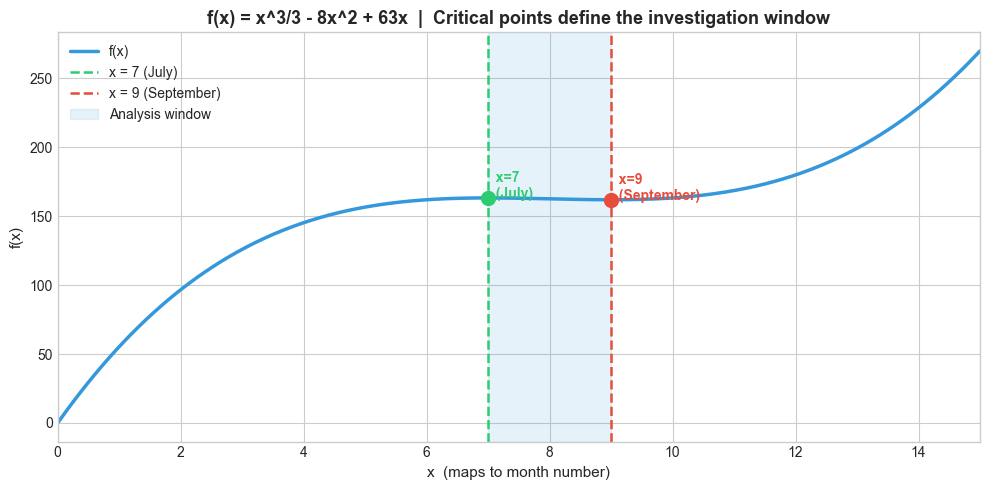

Figure saved to figures/act1_critical_points.png


In [7]:
# ── Step 5: Plot f(x) and mark the critical points ───────────────────────────
x_vals = np.linspace(0, 15, 500)

# Evaluate f(x) numerically using the derived R
f_vals = x_vals**3 / 3 - R * x_vals**2 + (R**2 - 1) * x_vals

# f(x) values at the critical points for marker placement
cp_y = [cp**3 / 3 - R * cp**2 + (R**2 - 1) * cp for cp in real_critical]

fig, ax = plt.subplots(figsize=(10, 5))

# Main curve
ax.plot(x_vals, f_vals, color=COLOR_NEUTRAL, linewidth=2.5, label='f(x)')

# Vertical lines and markers at critical points
colors = [COLOR_STABILITY, COLOR_STRESS]
for i, (cp, cp_y_val) in enumerate(zip(real_critical, cp_y)):
    month_label = MONTH_NAMES[int(round(cp))]
    ax.axvline(x=cp, color=colors[i], linestyle='--', linewidth=1.8,
               label=f'x = {cp:.0f} ({month_label})')
    ax.scatter([cp], [cp_y_val], color=colors[i], s=100, zorder=5)
    ax.annotate(
        f'  x={cp:.0f}\n  ({month_label})',
        xy=(cp, cp_y_val), fontsize=10,
        color=colors[i], fontweight='bold'
    )

# Shade the analysis window between the two critical points
ax.axvspan(real_critical[0], real_critical[1],
           alpha=0.12, color=COLOR_NEUTRAL, label='Analysis window')

ax.set_title(
    f"f(x) = x^3/3 - {R}x^2 + {R**2-1}x  |  Critical points define the investigation window",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('x  (maps to month number)', fontsize=11)
ax.set_ylabel('f(x)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, 15)

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act1_critical_points.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {FIGURES_DIR}/act1_critical_points.png')

### Act 1 — Interpretation

The function f(x) encodes the commissioner's intuition: the system has regions of smooth behaviour and regions where something shifts. The critical points — where f'(x) = 0 — mark exactly those inflection boundaries.

For this investigation:
- **R = 8** (derived from roll number digits 0, 4, 5, 8)
- Critical points at **x = 7** (July) and **x = 9** (September)
- The analysis window is **July, August, and September 2023**

These three months sit precisely between the two behavioural turning points of f(x) — the zone where the system is neither clearly stable nor clearly stressed. This is where we look.